## Homework 2 - Phase I & II Analysis Using CUSUM and EWMA Control Charts
### Dr. Austin Brown
### Kennesaw State University

**DUE: October 10, 2026 via D2L**

## Instructions: 

Buster's Sports Bar & Grill runs a busy draft beer program, pouring a house lager through a long-draw, CO2-driven tap system. State regulations require that a pint be poured within a fairly tight volume tolerance, and management has its own reasons to care about consistency too: an overpour on every pint adds up to real lost profit over a month, while a noticeable underpour draws customer complaints and bad reviews. The general manager has asked your quality control team to investigate the pour consistency at the bar's main tap station.

Pours are measured directly from the tap using a calibrated in-line flow meter, in ounces. The general manager has flagged a specific concern: as a CO2 regulator ages, line pressure can creep downward very gradually over weeks or months, producing more foam and a slightly smaller liquid pour -- a small, **sustained** drift, rather than a sudden jump. A chart that's only good at catching a sudden shift could easily miss this kind of slow creep until it's been happening for a long time. Pour volume is treated as a continuous, normally-distributed quality characteristic for this assignment.

Your team pulls a baseline (Phase I) sample of pour data from the tap right after a fresh regulator was installed: 5 pints sampled at random each shift, for 25 consecutive shifts. After validating statistical control, the team designs an appropriate CUSUM and EWMA monitoring scheme and applies it to 20 additional shifts of data (Phase II), collected several months later, to determine whether the aging regulator is already producing a detectable drift.

## Key Specifications

| Quantity | Value |
|---|---|
| Target pour volume | 16.00 oz |
| Lower Specification Limit (LSL) | 15.80 oz |
| Upper Specification Limit (USL) | 16.20 oz |
| Subgroup size (n) | 5 pints per shift |
| Phase I subgroups (m) | 25 shifts |
| Phase II subgroups (m) | 20 shifts |

## Define & Measure

### Q1: Briefly describe the purpose of this analysis

**Answer (Q1):** The purpose of this analysis is to find out whether the pour volume at Buster's main tap is stable and capable of meeting the 16.00 oz target (LSL 15.80 / USL 16.20), and then to find out whether an aging CO2 regulator has begun to pull pour volume down. In Phase I, we build a trustworthy baseline from data taken right after a new regulator was installed: remove assignable-cause shifts, estimate the process mean and standard deviation, and assess capability. In Phase II, we use CUSUM and EWMA charts built from that baseline to monitor 20 later shifts for a small, sustained drift. The result gives the general manager an evidence-based answer on whether the regulator must be replaced early.

### Q2: Identify the quality characteristic your team will monitor, and classify its units and measurement scale.

**Answer (Q2):** The quality characteristic is the **liquid volume of a single pint pour** of house lager, measured at the tap with a calibrated in-line flow meter. Its unit is **fluid ounces (oz)**. It is a **continuous, quantitative (variables) characteristic** on a **ratio scale** (there is a true zero, and ratios are meaningful: 16 oz is twice 8 oz). It is not attribute (pass/fail) data. We monitor it through subgroup means (and ranges) of n = 5 pours per shift.

### Q3: Briefly describe why a CUSUM and EWMA chart would be appropriate in this scenario, given the general manager's specific concern about the aging CO2 regulator. What are the limitations of these charts?

**Answer (Q3):** The manager's concern is a **small, sustained, gradual** downward drift in pour volume. A Shewhart $\bar{X}$ chart judges each shift on its own and has no memory, so it is slow to react to shifts below roughly 1.5 to 2 standard errors. **CUSUM** accumulates deviations from target across shifts, and **EWMA** averages the current mean with a geometrically weighted history. Both therefore build evidence from many slightly-low shifts and are much more sensitive to this kind of creep than a Shewhart chart. In this very data set, no Phase II shift mean falls outside the Phase I $\bar{X}$ limits, yet both memory charts signal.

**Limitations:**
- Both are tuned to a particular shift size ($K$ or $\lambda$) and are less effective than a Shewhart chart for large, sudden jumps. They are often paired with an $\bar{X}$ chart for that reason.
- They assume independent, approximately normal observations. Autocorrelation or non-normality distorts the in-control ARL and produces false alarms.
- They rely on Phase I estimates of $\mu_0$ and $\sigma$. If the Phase I data were not truly in control, or $m$ is small, the limits are off.
- They monitor the mean only. Variability needs its own chart (R or S).
- They are harder to explain, and a signal does not say *why* the shift occurred or how big it is.
- CUSUM can accumulate "inertia" after a shift ends, and a smoothed EWMA can lag after a sudden change.

## Analyze

### Q4: Read the Phase I data into R. Calculate and report the subgroup means and ranges, and use them to estimate the process mean and process standard deviation.

In [ ]:
## Q4 Code ##
library(readxl)

phase1 <- read_excel("BustersSportsBar_PhaseI.xlsx")
pours  <- as.matrix(phase1[, paste0("Pour", 1:5)])
n <- ncol(pours)   # 5 pints per shift
m <- nrow(pours)   # 25 shifts

xbar <- rowMeans(pours)                                  # subgroup means
R    <- apply(pours, 1, function(x) max(x) - min(x))     # subgroup ranges

q4_table <- data.frame(Shift = phase1$Shift, Xbar = round(xbar, 4), R = round(R, 4))
print(q4_table, row.names = FALSE)

# Control chart constants for n = 5
d2 <- 2.326; D3 <- 0; D4 <- 2.114; A2 <- 0.577

xbarbar   <- mean(xbar)       # estimate of process mean
Rbar      <- mean(R)
sigma_hat <- Rbar / d2        # estimate of process standard deviation

cat(sprintf("Grand mean  = %.4f oz\n", xbarbar))
cat(sprintf("Rbar        = %.4f oz\n", Rbar))
cat(sprintf("sigma_hat   = Rbar/d2 = %.4f oz\n", sigma_hat))


**Answer (Q4):** Subgroup means and ranges (all 25 shifts, n = 5):

| Shift | Mean (oz) | Range (oz) | Shift | Mean (oz) | Range (oz) |
|---|---|---|---|---|---|
| 1 | 16.0890 | 0.2469 | 14 | 16.0621 | 0.1993 |
| 2 | 16.0560 | 0.0783 | 15 | 16.0064 | 0.1643 |
| 3 | 16.0514 | 0.0801 | 16 | 16.0415 | 0.1941 |
| 4 | 16.0678 | 0.1791 | 17 | 16.0551 | 0.1180 |
| 5 | 15.9875 | 0.0641 | 18 | 16.0831 | 0.1488 |
| 6 | 16.0378 | 0.2016 | 19 | 15.9957 | 0.6818 |
| 7 | 16.0534 | 0.1548 | 20 | 16.0205 | 0.0912 |
| 8 | 16.0952 | 0.2202 | 21 | 16.1008 | 0.0724 |
| 9 | 16.0668 | 0.1927 | 22 | 16.0255 | 0.1377 |
| 10 | 16.0482 | 0.0942 | 23 | 16.0923 | 0.2165 |
| 11 | 16.0458 | 0.1200 | 24 | 16.0351 | 0.2231 |
| 12 | 15.7078 | 0.2178 | 25 | 16.0605 | 0.1919 |
| 13 | 16.0786 | 0.1995 | | | |

Using all 25 subgroups: $\bar{\bar{x}}$ = **16.0386 oz**, $\bar{R}$ = 0.1795 oz, so $\hat{\sigma} = \bar{R}/d_2 = 0.1795/2.326$ = **0.0772 oz**. These are preliminary: they are inflated by the assignable causes found in Q5 and Q6.

### Q5: Construct a Phase I $R$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

In [ ]:
## Q5 Code ##
# Helper to draw a control chart. Grey points = already removed, red = out of control.
plot_chart <- function(y, cl, ucl, lcl, main, ylab, retained = rep(TRUE, length(y))) {
  idx <- seq_along(y)
  ooc <- retained & (y > ucl | y < lcl)
  plot(idx, y, type = "l", col = "grey50", ylim = range(c(y, ucl, lcl)),
       xlab = "Shift", ylab = ylab, main = main)
  points(idx, y, pch = 19, col = ifelse(ooc, "red", ifelse(retained, "black", "grey80")))
  abline(h = cl, col = "darkgreen")
  abline(h = c(lcl, ucl), col = "red", lty = 2)
  if (any(ooc)) text(idx[ooc], y[ooc], labels = idx[ooc], pos = 3, col = "red")
}

keep_R <- rep(TRUE, m)
iter <- 0
repeat {
  iter  <- iter + 1
  Rbar_k <- mean(R[keep_R])
  UCL_R <- D4 * Rbar_k
  LCL_R <- D3 * Rbar_k
  plot_chart(R, Rbar_k, UCL_R, LCL_R,
             main = paste("Phase I R chart - iteration", iter),
             ylab = "Range (oz)", retained = keep_R)
  bad <- which(keep_R & (R > UCL_R | R < LCL_R))
  cat(sprintf("Iteration %d: Rbar = %.4f, LCL = %.4f, UCL = %.4f, OOC: %s\n",
              iter, Rbar_k, LCL_R, UCL_R,
              ifelse(length(bad) == 0, "none", paste(bad, collapse = ", "))))
  if (length(bad) == 0) break
  keep_R[bad] <- FALSE
}
cat("Subgroups retained after R chart:", sum(keep_R), "of", m, "\n")


**Answer (Q5):**

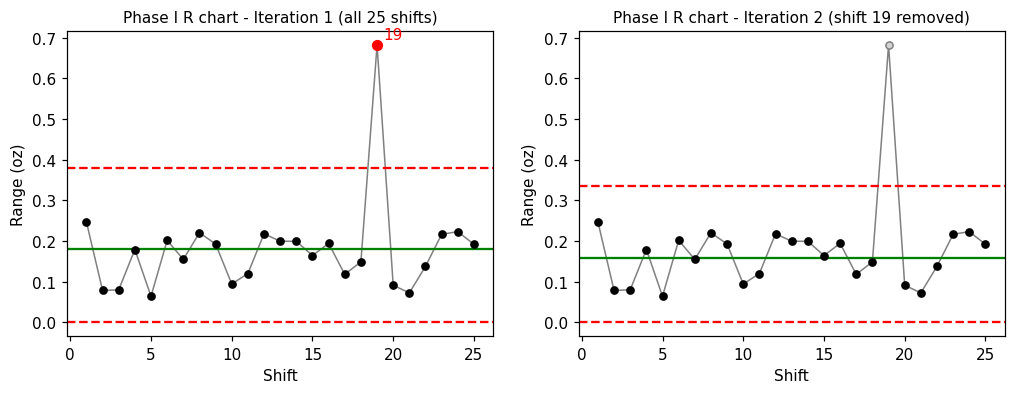

- **Iteration 1** (all 25 shifts): $\bar R$ = 0.1795, LCL = 0, UCL = 0.3795. **Shift 19 is out of control** (R = 0.6818 oz); no other range exceeds the UCL.
- **Iteration 2** (24 shifts, #19 removed): $\bar R$ = 0.1586, UCL = 0.3353. All ranges fall inside the limits, so **the R chart shows statistical control** and the variability is stable. 24 subgroups are retained.

*Context for shift 19:* Its pours span 15.70 to 16.38 oz, which is wildly inconsistent within a single shift, while the shift mean (15.996) is unremarkable. That pattern fits an erratic, foamy tap: air in the line, a keg change, or a freshly tapped keg surging, then settling; an untrained or rushed pourer; or a flow-meter or recording glitch. This is a possible explanation only, and it should be confirmed against the shift log. Because the cause is assignable and not part of everyday behavior, the subgroup is omitted from the baseline.

### Q6: Using only the subgroups retained after Q5, construct the Phase I $\bar{X}$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

In [ ]:
## Q6 Code ##
keep_X <- keep_R           # start from the subgroups retained after Q5
iter <- 0
repeat {
  iter <- iter + 1
  xbb  <- mean(xbar[keep_X])
  Rb   <- mean(R[keep_X])
  UCL_X <- xbb + A2 * Rb
  LCL_X <- xbb - A2 * Rb
  plot_chart(xbar, xbb, UCL_X, LCL_X,
             main = paste("Phase I Xbar chart - iteration", iter),
             ylab = "Subgroup mean (oz)", retained = keep_X)
  bad <- which(keep_X & (xbar > UCL_X | xbar < LCL_X))
  cat(sprintf("Iteration %d: center = %.4f, LCL = %.4f, UCL = %.4f, OOC: %s\n",
              iter, xbb, LCL_X, UCL_X,
              ifelse(length(bad) == 0, "none", paste(bad, collapse = ", "))))
  if (length(bad) == 0) break
  keep_X[bad] <- FALSE
}

# Final Phase I estimates
mu_hat     <- mean(xbar[keep_X])
Rbar_final <- mean(R[keep_X])
sigma_hat  <- Rbar_final / d2
cat("Retained shifts:", sum(keep_X), "| removed:", paste(which(!keep_X), collapse = ", "), "\n")

# Confirm the R chart is still in control for the final retained set
cat(sprintf("Final R chart: UCL = %.4f, max retained R = %.4f\n",
            D4 * Rbar_final, max(R[keep_X])))
cat(sprintf("mu_hat = %.4f oz, Rbar = %.4f oz, sigma_hat = %.4f oz\n",
            mu_hat, Rbar_final, sigma_hat))


**Answer (Q6):**

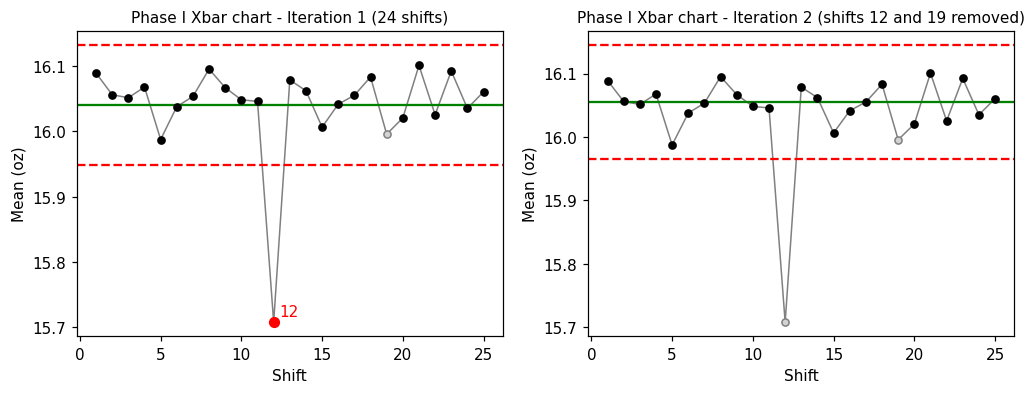

- **Iteration 1** (24 shifts): center = 16.0403, limits 15.9488 to 16.1319. **Shift 12 is out of control** (mean = 15.708 oz, far below the LCL).
- **Iteration 2** (23 shifts, #12 and #19 removed): center = **16.0548**, $\bar R$ = 0.1560, limits **15.9648 to 16.1448**. All 23 subgroup means are inside the limits, so **the $\bar{X}$ chart shows statistical control**. The R chart also remains in control on the final set (UCL = 0.3299, largest retained range = 0.2469).

*Context for shift 12:* All five pours were low (15.58 to 15.80 oz) with ordinary spread, so the whole shift ran under-poured. That pattern points to a shift-wide cause, such as low line pressure or foaming (an empty or nearly empty CO2 cylinder, a regulator setting changed or reset, a warm or nearly empty keg), or a meter calibration problem. Since it is a one-shift event, it is excluded from the baseline.

**Final Phase I estimates:** $\hat\mu$ = **16.0548 oz**, $\hat\sigma = \bar R/d_2 = 0.1560/2.326$ = **0.0671 oz** (so $\hat\sigma_{\bar x} = \hat\sigma/\sqrt5$ = 0.0300 oz).

### Q7: Using your final Phase I estimates of the process mean and process standard deviation, perform a process capability analysis against the specification limits given above. Report and interpret $PCR$, $C_p$, $C_{pk}$, and $C_{pm}$. Is the process capable of meeting specification? Is it well-centered?

In [ ]:
## Q7 Code ##
LSL <- 15.80; USL <- 16.20; target <- 16.00

Cp  <- (USL - LSL) / (6 * sigma_hat)
PCR <- 1 / Cp                                   # proportion of spec band used by the process
Cpu <- (USL - mu_hat) / (3 * sigma_hat)
Cpl <- (mu_hat - LSL) / (3 * sigma_hat)
Cpk <- min(Cpu, Cpl)
Cpm <- Cp / sqrt(1 + ((mu_hat - target) / sigma_hat)^2)

p_out <- pnorm(LSL, mu_hat, sigma_hat) + pnorm(USL, mu_hat, sigma_hat, lower.tail = FALSE)

cat(sprintf("PCR = %.3f\nCp = %.3f\nCpu = %.3f, Cpl = %.3f\nCpk = %.3f\nCpm = %.3f\n",
            PCR, Cp, Cpu, Cpl, Cpk, Cpm))
cat(sprintf("Expected fraction outside spec = %.4f (%.0f ppm)\n", p_out, p_out * 1e6))

# Visual check against the specs
v <- as.vector(t(pours[keep_X, ]))
hist(v, breaks = 18, freq = FALSE, col = "steelblue", border = "white",
     main = "Phase I pours (retained) vs. specification", xlab = "Pour volume (oz)")
curve(dnorm(x, mu_hat, sigma_hat), add = TRUE, lwd = 2)
abline(v = c(LSL, USL), col = "red", lty = 2); abline(v = target, col = "darkgreen")


**Answer (Q7):** (LSL = 15.80, USL = 16.20, target = 16.00, $\hat\mu$ = 16.0548, $\hat\sigma$ = 0.0671)

| Index | Value |
|---|---|
| PCR | **1.006** |
| $C_p$ | **0.994** |
| $C_{pu}$ / $C_{pl}$ | 0.721 / 1.266 |
| $C_{pk}$ | **0.721** |
| $C_{pm}$ | **0.770** |

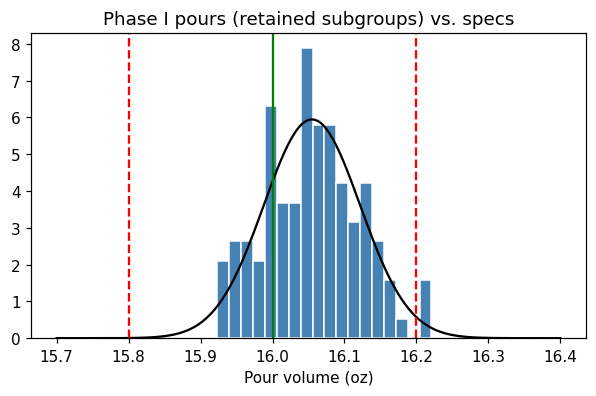

**Interpretation:**
- **PCR = 1.006:** the natural spread (6σ) uses about 100.6% of the 0.40 oz tolerance band, so the process has no spare room even if perfectly centered.
- **$C_p$ = 0.994 (< 1):** the *potential* capability is marginal. Even centered at 16.00, it would just about fit, and well below the common 1.33 benchmark.
- **$C_{pk}$ = 0.721:** much lower than $C_p$, because the process mean is above target, toward the USL. $C_{pu}$ is the limiting side (the lower side, $C_{pl}$ = 1.266, is fine).
- **$C_{pm}$ = 0.770:** this also penalizes the offset from target and confirms the process is off-target.

**Conclusion:** The process is **not capable** of reliably meeting specification. About **1.5%** of pours (~15,288 ppm) are expected to fall outside 15.80 to 16.20, nearly all of them overpours above the USL. It is **not well-centered**: the mean runs about 0.055 oz (0.8σ) high, which is also a small "give-away" on every pint. Re-centering to 16.00 would raise $C_{pk}$ to about 0.99 but would not fix the marginal $C_p$, which needs reduced pour-to-pour variation.

## Improve

### Q8: The general manager wants a monitoring scheme that reliably detects a sustained shift of about one process standard deviation (representing early-stage regulator drift) while keeping the in-control ARL around 370-500. Using the design guidance from lecture, select and briefly justify: (a) the CUSUM slack value $K$ and decision interval $H$, and (b) the EWMA smoothing constant $\lambda$ and width $L$, that you will carry forward into your Phase II monitoring plan.

**Answer (Q8):** The design goal is a sustained shift of about **1σ** with in-control ARL₀ between 370 and 500.

**(a) CUSUM:** $k = 0.5$ and $h = 5$ (in σ-units of the plotted statistic, $\hat\sigma_{\bar x}$ = 0.0300 oz). The slack is set to half the shift to be detected ($k = \delta/2 = 0.5$), which is the standard optimal choice for a 1σ shift. In oz, **K = 0.0150 oz** and **H = 0.1500 oz**. The standard design table gives ARL₀ ≈ 465 (two-sided) and ARL₁ ≈ 10 shifts for a 1σ shift. A quick simulation check gave an ARL₀ of about 470 to 480.

**(b) EWMA:** $\lambda = 0.10$ and $L = 2.814$. Small λ (0.05 to 0.25) is the recommended range for detecting small shifts, and λ = 0.10 with L = 2.814 gives ARL₀ ≈ 500, at the top of the requested range. ARL₁ is roughly 10 for a 1σ shift. Limits are time-varying, $\mu_0 \pm L\hat\sigma_{\bar x}\sqrt{\tfrac{\lambda}{2-\lambda}[1-(1-\lambda)^{2i}]}$, approaching **16.0548 ± 0.0194** (about 16.0355 to 16.0742).

*Note on "1σ":* Both charts plot **subgroup means**, so a 1σ shift is read in standard-error units (0.030 oz). A 1σ shift in individual pours (0.067 oz = 2.2 standard errors) would be caught much faster, in about 2 to 4 shifts, at no cost to ARL₀.

In [ ]:
## Q8 Code: design parameters carried into Phase II ##
sigma_xbar <- sigma_hat / sqrt(n)

# (a) Tabular CUSUM, in units of sigma_xbar
k <- 0.5; h <- 5
K <- k * sigma_xbar
H <- h * sigma_xbar

# (b) EWMA
lambda <- 0.10; L <- 2.814
ewma_hw_inf <- L * sigma_xbar * sqrt(lambda / (2 - lambda))   # asymptotic half-width

cat(sprintf("sigma_xbar = %.4f\nCUSUM: K = %.4f oz, H = %.4f oz\n", sigma_xbar, K, H))
cat(sprintf("EWMA: lambda = %.2f, L = %.3f, asymptotic limits = %.4f +/- %.4f\n",
            lambda, L, mu_hat, ewma_hw_inf))


## Control

### Q9: Read the Phase II data into R. Using your final Phase I estimates from Q6 and the CUSUM parameters you selected in Q9, construct the Phase II CUSUM chart. Does the chart signal an out-of-control condition? If so, at which shift number?

In [ ]:
## Q9 Code ##
phase2 <- read_excel("BustersSportsBar_PhaseII.xlsx")
pours2 <- as.matrix(phase2[, paste0("Pour", 1:5)])
m2     <- nrow(pours2)
xbar2  <- rowMeans(pours2)

# Tabular CUSUM using Phase I estimates
Cplus <- Cminus <- numeric(m2)
cp_prev <- cm_prev <- 0
for (i in 1:m2) {
  cp_prev <- max(0, xbar2[i] - (mu_hat + K) + cp_prev)
  cm_prev <- max(0, (mu_hat - K) - xbar2[i] + cm_prev)
  Cplus[i] <- cp_prev
  Cminus[i] <- cm_prev
}
cusum_signal <- which(Cplus > H | Cminus > H)
cat("CUSUM first signal at shift:", ifelse(length(cusum_signal) == 0, "none", cusum_signal[1]), "\n")

# Chart: plot lower sum as negative so both sides share one axis
plot(1:m2, Cplus, type = "b", pch = 19, ylim = c(-1.3 * max(H, max(Cminus)), 1.3 * H),
     xlab = "Shift", ylab = "Cumulative sum (oz)", main = "Phase II CUSUM")
lines(1:m2, -Cminus, type = "b", pch = 19, col = "blue")
abline(h = c(-H, H), col = "red", lty = 2); abline(h = 0, col = "darkgreen")
points(cusum_signal, -Cminus[cusum_signal], col = "red", pch = 19, cex = 1.4)
legend("topright", c("C+", "-C-"), col = c("black", "blue"), pch = 19, bty = "n")

# Estimated start of drift and size once the lower side signals
N_minus <- sum(Cminus[1:cusum_signal[1]] > 0 & seq_len(cusum_signal[1]) > max(c(0, which(Cminus[1:cusum_signal[1]] == 0))))
mu_new  <- mu_hat - K - Cminus[cusum_signal[1]] / N_minus
cat(sprintf("Drift began ~shift %d; estimated new mean = %.4f oz\n",
            cusum_signal[1] - N_minus + 1, mu_new))


**Answer (Q9):**

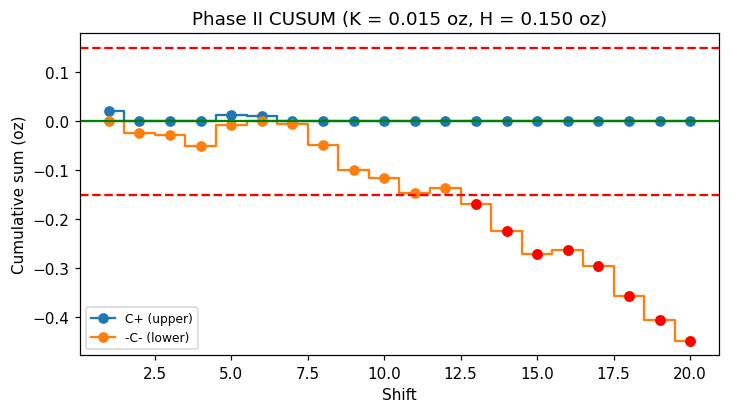

**Yes, the CUSUM signals out of control, at shift 13.** The lower CUSUM $C^-$ reaches 0.169 oz, above H = 0.150 oz, and stays above H through shift 20. It was just below H at shift 11 (0.147 oz), and the upper CUSUM never signals. The lower side first becomes nonzero at shift 7, which puts the start of the drift near shift 7. The estimated mean at the signal is $\hat\mu_{new} = \mu_0 - K - C^-/N$ = 16.0157 oz, about 0.04 oz (0.6σ) below the Phase I mean.

### Q10: Using your final Phase I estimates from Q6 and the EWMA parameters you selected in Q8, construct the Phase II EWMA chart. Does the chart signal an out-of-control condition? If so, at which shift number?

In [ ]:
## Q10 Code ##
z_ewma <- numeric(m2)
z_prev <- mu_hat
for (i in 1:m2) {
  z_prev <- lambda * xbar2[i] + (1 - lambda) * z_prev
  z_ewma[i] <- z_prev
}
i_seq <- 1:m2
hw       <- L * sigma_xbar * sqrt(lambda / (2 - lambda) * (1 - (1 - lambda)^(2 * i_seq)))
ewma_UCL <- mu_hat + hw
ewma_LCL <- mu_hat - hw
ewma_signal <- which(z_ewma > ewma_UCL | z_ewma < ewma_LCL)
cat("EWMA signals at shift(s):", paste(ewma_signal, collapse = ", "), "\n")

plot(i_seq, xbar2, type = "b", pch = 1, col = "grey60", ylim = range(c(xbar2, ewma_LCL, ewma_UCL)),
     xlab = "Shift", ylab = "Pour volume (oz)", main = "Phase II EWMA chart")
lines(i_seq, z_ewma, type = "b", pch = 19, col = "blue")
lines(i_seq, ewma_UCL, type = "s", col = "red", lty = 2)
lines(i_seq, ewma_LCL, type = "s", col = "red", lty = 2)
abline(h = mu_hat, col = "darkgreen")
points(ewma_signal, z_ewma[ewma_signal], col = "red", pch = 19, cex = 1.4)


**Answer (Q10):**

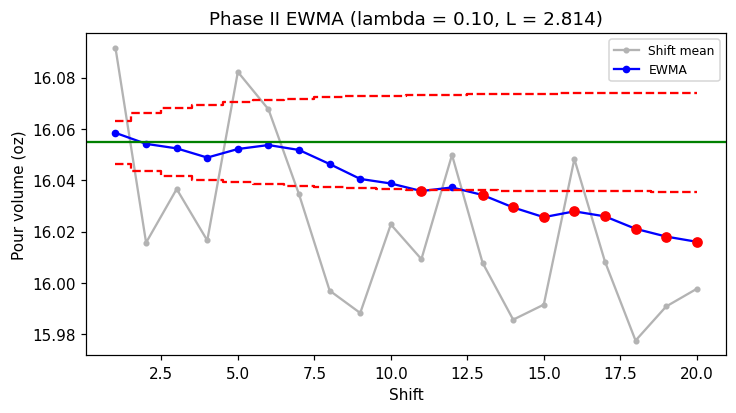

**Yes, the EWMA signals out of control, first at shift 11,** where z = 16.0358 falls just below the lower limit of 16.0364. This first signal is marginal (by about 0.0006 oz), and the statistic comes back inside the limits at shift 12 (16.0372). From **shift 13 onward the EWMA stays below the LCL every shift** (through shift 20), a clear, sustained downward signal. The upper limit is never crossed.

### Q11: Compare the results of Q9 and Q10. Which chart detected the shift more quickly, if either? Is this consistent with what you would expect, given what you know about the relative sensitivity of CUSUM and EWMA charts to small, sustained shifts? Briefly explain.

In [ ]:
## Q11 Code ##
first_cusum <- cusum_signal[1]
first_ewma  <- ewma_signal[1]

comparison <- data.frame(
  Shift = i_seq, Xbar = round(xbar2, 4),
  Cminus = round(Cminus, 3), CUSUM_OOC = (Cplus > H | Cminus > H),
  EWMA = round(z_ewma, 4), EWMA_LCL = round(ewma_LCL, 4),
  EWMA_UCL = round(ewma_UCL, 4), EWMA_OOC = (z_ewma > ewma_UCL | z_ewma < ewma_LCL)
)
print(comparison, row.names = FALSE)
cat("First CUSUM signal:", first_cusum, "| first EWMA signal:", first_ewma, "\n")

# Reference: would a Shewhart Xbar chart (Phase I limits) have signaled?
UCL_X <- mu_hat + A2 * Rbar_final; LCL_X <- mu_hat - A2 * Rbar_final
cat("Shewhart Xbar OOC shifts in Phase II:",
    ifelse(any(xbar2 > UCL_X | xbar2 < LCL_X), paste(which(xbar2 > UCL_X | xbar2 < LCL_X), collapse = ", "), "none"), "\n")

# Reference: has the variability changed? (Phase II ranges vs. Phase I R chart)
R2 <- apply(pours2, 1, function(x) max(x) - min(x))
cat("Phase II ranges above Phase I UCL:", paste(which(R2 > D4 * Rbar_final), collapse = ", "), "\n")
cat(sprintf("Mean of Phase II shifts 1-10 = %.4f; shifts 13-20 = %.4f\n", mean(xbar2[1:10]), mean(xbar2[13:20])))


**Answer (Q11):**

| Shift | Mean | C- (oz) | CUSUM signal | EWMA | EWMA LCL | EWMA signal |
|---|---|---|---|---|---|---|
| 1 | 16.0916 | 0.000 |  | 16.0585 | 16.0464 |  |
| 2 | 16.0157 | 0.024 |  | 16.0542 | 16.0434 |  |
| 3 | 16.0366 | 0.027 |  | 16.0524 | 16.0415 |  |
| 4 | 16.0166 | 0.051 |  | 16.0489 | 16.0402 |  |
| 5 | 16.0822 | 0.008 |  | 16.0522 | 16.0392 |  |
| 6 | 16.0677 | 0.000 |  | 16.0537 | 16.0384 |  |
| 7 | 16.0345 | 0.005 |  | 16.0518 | 16.0378 |  |
| 8 | 15.9970 | 0.048 |  | 16.0463 | 16.0373 |  |
| 9 | 15.9883 | 0.100 |  | 16.0405 | 16.0369 |  |
| 10 | 16.0228 | 0.117 |  | 16.0388 | 16.0367 |  |
| 11 | 16.0093 | 0.147 |  | 16.0358 | 16.0364 | **yes** |
| 12 | 16.0499 | 0.137 |  | 16.0372 | 16.0362 |  |
| 13 | 16.0078 | 0.169 | **yes** | 16.0343 | 16.0361 | **yes** |
| 14 | 15.9857 | 0.223 | **yes** | 16.0294 | 16.0359 | **yes** |
| 15 | 15.9916 | 0.271 | **yes** | 16.0256 | 16.0359 | **yes** |
| 16 | 16.0483 | 0.263 | **yes** | 16.0279 | 16.0358 | **yes** |
| 17 | 16.0083 | 0.294 | **yes** | 16.0259 | 16.0357 | **yes** |
| 18 | 15.9776 | 0.357 | **yes** | 16.0211 | 16.0357 | **yes** |
| 19 | 15.9908 | 0.406 | **yes** | 16.0181 | 16.0356 | **yes** |
| 20 | 15.9977 | 0.448 | **yes** | 16.0160 | 16.0356 | **yes** |

- **Detection:** the EWMA flagged the shift first (shift **11**, marginally), and the CUSUM signaled at shift **13**. By shift 13, both charts are signaling and stay signaling through shift 20. At shift 11 the CUSUM was at 0.147 oz against H = 0.150 oz, so it came very close.
- **Is this consistent with expectation?** Largely yes. Both charts are designed for the same kind of small, sustained shift, with similar ARL₀ (about 465 to 500) and similar ARL₁ (about 10 shifts for a 1σ shift), so they are expected to perform comparably and to differ by only a shift or two on any single data set. A two-shift gap is well within that normal variation, and I would not read it as EWMA being generally better. The EWMA's earlier flag is also borderline and not persistent, so I would treat shift 13 as the point where both agree.
- **Why not a Shewhart chart?** The lowest Phase II shift mean (15.978, shift 18) is still inside the Phase I $\bar X$ limits (15.9648 to 16.1448), so an ordinary $\bar X$ chart would have shown **no signal at all** in 20 shifts. This is exactly the situation CUSUM and EWMA are built for.
- **Variability:** Phase II ranges look unchanged (mean range 0.1399 vs. Phase I 0.1560); only shift 15 (R = 0.3304) touches the R-chart UCL (0.3299), by a hair. The change is in the **mean**, not the spread.

### Q13: Provide an overview of the results that the general manager can provide to Buster's ownership. Does the CO2 regulator need to be replaced ahead of schedule, or can it run as planned?

**Answer (Q13) - Summary for ownership:**

**What we did.** We took a baseline right after the new CO2 regulator went in, then watched 20 later shifts with two charts that are built to catch slow drift.

**What we found.**
- **Baseline:** Two shifts were unusual (a shift with erratic pours and one with every pour low) and were set aside. For the rest, the average pour was **16.055 oz**, about 0.05 oz over the 16.00 oz target, with normal pint-to-pint variation of about 0.07 oz.
- **Capability:** On the baseline, the tap was **not capable** of staying inside 15.80 to 16.20 oz ($C_{pk}$ = 0.72). It was running high, with about 1.5% of pours expected to fall out of spec, nearly all overpours, which means giving away beer.
- **Drift is real:** Both charts show a sustained **downward** drift, consistent with the regulator aging. The CUSUM signaled at shift 13, and the EWMA at shift 11 (confirmed from shift 13). The drift appears to have started around shift 7. A conventional chart would have missed it.
- **Size so far:** The average pour fell from 16.055 oz to 16.001 oz over the last 8 shifts (shifts 13 to 20), about 0.05 oz. This drift has *so far moved the tap toward the target*. No individual Phase II pour was out of spec, and the expected out-of-spec rate is now about 0.3%, with $C_{pk}$ about 0.99.

**Recommendation.** Do not run the regulator unattended to its planned replacement date, but this is **not an emergency**.
1. The drift is statistically established and not stopping, so the mean will keep sliding below 16.00 oz, into underpours, foam and complaints. We recommend inspecting and recalibrating the regulator and CO2 supply now, and **moving replacement up to the next convenient maintenance window**.
2. Keep the CUSUM/EWMA monitoring running. Replace right away if the shift average falls below about 15.97 oz, or if individual pours begin to fall below 15.80 oz.
3. Replacing the regulator alone will likely reset the mean to about 16.05 oz, i.e. back to overpouring. After servicing, **re-target the tap to 16.00 oz**, and look at ways to reduce pour-to-pour variation (line cleaning, temperature, pour training). Even when centered, $C_p$ is only about 1.0, which is why the process has little margin.

*Caveats:* This is based on 20 Phase II shifts and one tap. The explanations for the unusual Phase I shifts are plausible but unconfirmed, and the analysis assumes pours are approximately normal and independent.